# Практика Полиномиальной регрессии
-----

Данные - `DATA/Advertising.csv`
3 Признака, которые влияют на целевую переменную:
1. Реклама на Телевидении `TV`
2. Реклама на Радио `radio`
3. Реклама в Газетах `newspaper`

Целевая переменная (target) - Продажи `salses`

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv('~//Documents//University//Анализ данных//'
                 '1. ML Course ipynb//08-Linear-Regression-Models//Advertising.csv')
df.head()

,TV,radio,newspaper,sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9


In [4]:
'Отделяю признаки и целевую переменную'
X = df.drop('sales', axis=1)
y = df['sales']

X

,TV,radio,newspaper
0,230.1,37.8,69.2
1,44.5,39.3,45.1
2,17.2,45.9,69.3
3,151.5,41.3,58.5
4,180.8,10.8,58.4
...,...,...,...
195,38.2,3.7,13.8
196,94.2,4.9,8.1
197,177.0,9.3,6.4
198,283.6,42.0,66.2


## 1. Подготовка признаков для модели
Общая формула для двух признаков $X_1, X_2$:
$$1, X_1, X_2, X_1^2, X_1X_2, X_2^2$$
Как можно заметить, помимо полинома тут есть и произведение признаков.

In [5]:
from sklearn.preprocessing import PolynomialFeatures

In [6]:
polynomial_converter = PolynomialFeatures(
    degree=2, # До какой степени создавать полином
    include_bias=False, # Смещение относительно нуля по целевой переменной
    interaction_only=False, # Оставить только произведения признаков БЕЗ степеней порядков
)

In [7]:
'Анализируем признаки'
polynomial_converter.fit(X)

'Создаем признаки'
polynomial_converter.transform(X)

array([[ 230.1 ,   37.8 ,   69.2 , ..., 1428.84, 2615.76, 4788.64],
       [  44.5 ,   39.3 ,   45.1 , ..., 1544.49, 1772.43, 2034.01],
       [  17.2 ,   45.9 ,   69.3 , ..., 2106.81, 3180.87, 4802.49],
       ...,
       [ 177.  ,    9.3 ,    6.4 , ...,   86.49,   59.52,   40.96],
       [ 283.6 ,   42.  ,   66.2 , ..., 1764.  , 2780.4 , 4382.44],
       [ 232.1 ,    8.6 ,    8.7 , ...,   73.96,   74.82,   75.69]])

Теперь вместо 3 исходных признаков у нас их 9. По формуле их должно быть 10, но мы поставили `include_bias=False`, поэтому признак смещения не учитывается.

In [8]:
'Создаю переменную для удобства в дальнейшем'
poly_features = polynomial_converter.fit_transform(X)

## 2. Разбиение данных на обучающий и тестовый набор
ВАЖНО! В функцию `train_test_split()` передаем Полиномиальные признаки, которые получились на предыдущем шаге.

In [9]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(poly_features, y, test_size=0.3, random_state=42)

## 3. Создание и обучение модели

In [10]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

test_predictions = model.predict(X_test)

## 4. Оценка модели

In [11]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, root_mean_squared_error
mse = mean_squared_error(y_test, test_predictions)
mae = mean_absolute_error(y_test, test_predictions)
r2 = r2_score(y_test, test_predictions)
rmse = root_mean_squared_error(y_test, test_predictions)

print(mse, mae, r2, rmse)

0.5231944949055388 0.5905974833807998 0.9808386009966374 0.7233218473857532


## 5. Обучение на всех данных и Визуализация

In [12]:
predicted_full = model.predict(poly_features)

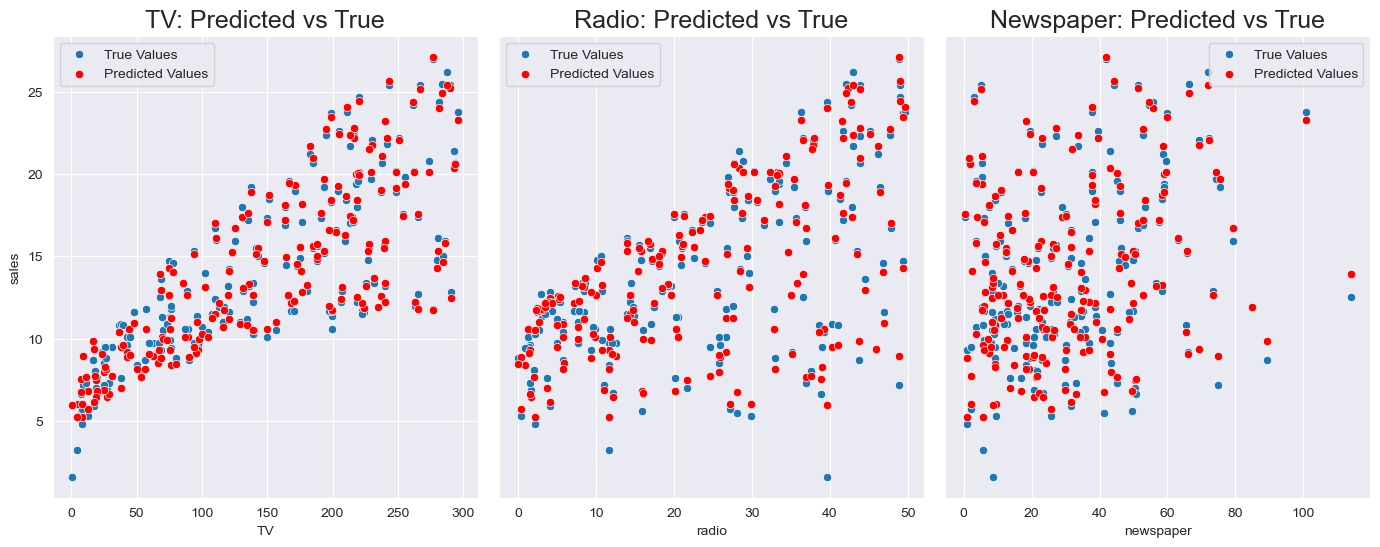

In [13]:
fig, ax = plt.subplots(1, 3, figsize=(17, 6))

ax[0].set_title('TV: Predicted vs True', fontsize=18)
sns.scatterplot(data=df, x='TV', y='sales', ax=ax[0], label='True Values')
sns.scatterplot(x=df['TV'], y=predicted_full, ax=ax[0], color='red', label='Predicted Values')

ax[1].set_title('Radio: Predicted vs True', fontsize=18)
ax[1].set_yticks([])
sns.scatterplot(data=df, x='radio', y='sales', ax=ax[1], label='True Values')
sns.scatterplot(x=df['radio'], y=predicted_full, ax=ax[1], color='red', label='Predicted Values')

ax[2].set_title('Newspaper: Predicted vs True', fontsize=18)
ax[2].set_yticks([])
sns.scatterplot(data=df, x='newspaper', y='sales', ax=ax[2], label='True Values')
sns.scatterplot(x=df['newspaper'], y=predicted_full, ax=ax[2], color='red', label='Predicted Values')

fig.subplots_adjust(wspace=0.05)


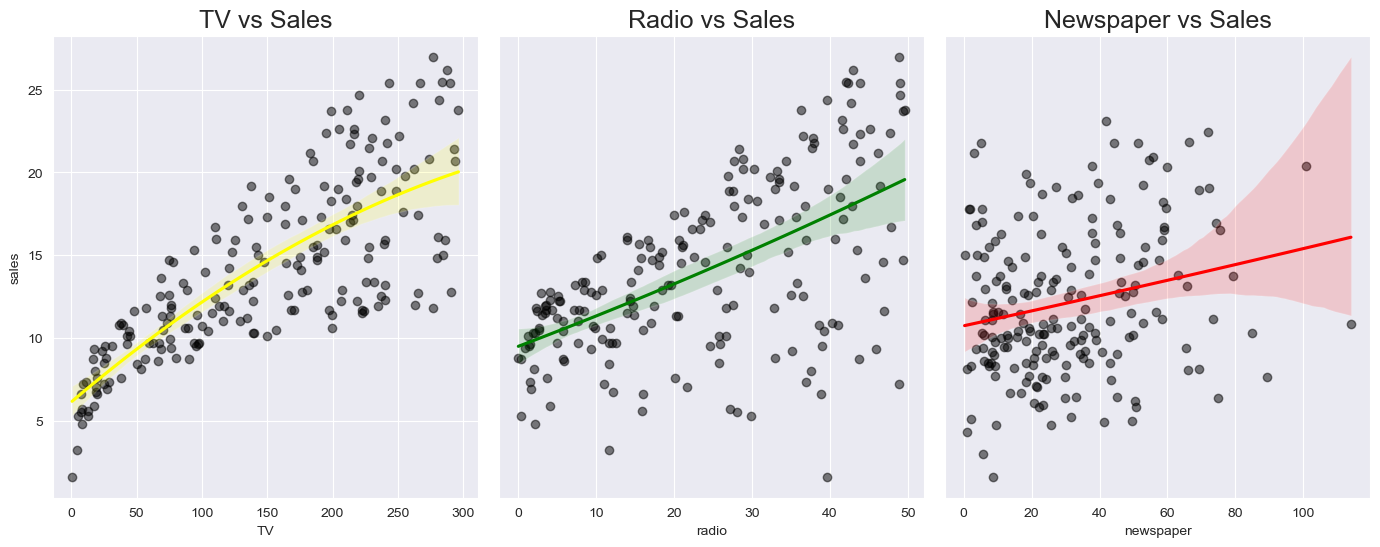

In [14]:
fig, ax = plt.subplots(1, 3, figsize=(17, 6))
ax[0].set_title('TV vs Sales', fontsize=18)
sns.regplot(data=df, x='TV', y='sales', ax=ax[0], order=2,
            line_kws={'color': 'yellow'}, scatter_kws={'color': 'black', 'alpha': 0.5})

ax[1].set_title('Radio vs Sales', fontsize=18)
ax[1].set_yticks([])
sns.regplot(data=df, x='radio', y='sales', ax=ax[1], order=2,
            line_kws={'color': 'green'}, scatter_kws={'color': 'black', 'alpha': 0.5})
ax[1].set_ylabel('')

ax[2].set_title('Newspaper vs Sales', fontsize=18)
ax[2].set_yticks([])
sns.regplot(data=df, x='newspaper', y='sales', ax=ax[2], order=2,
            line_kws={'color': 'red'}, scatter_kws={'color': 'black', 'alpha': 0.5})
ax[2].set_ylabel('')


fig.subplots_adjust(wspace=0.05)


# Подбор лучших параметров (степени полинома) через цикл

In [15]:
train_rmse_errors = [] # Тут буду хранить метрику RMSE для обучающего набора данных
test_rmse_errors = [] # Для тестового набора данных

In [16]:
for degree in range(2, 11): # Буду перебирать степени полинома от 2 до 10
    polynomial_converter = PolynomialFeatures(
        degree=degree, include_bias=False, interaction_only=False,
    )

    poly_features = polynomial_converter.fit_transform(X)

    X_train, X_test, y_train, y_test = train_test_split(poly_features, y, test_size=0.3,)

    model = LinearRegression()
    model.fit(X_train, y_train)

    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)

    train_rmse = root_mean_squared_error(y_train, train_pred)
    test_rmse = root_mean_squared_error(y_test, test_pred)

    train_rmse_errors.append(train_rmse)
    test_rmse_errors.append(test_rmse)



In [17]:
train_rmse_errors

[0.5112477412013096,
 0.5020870953992478,
 0.34336399057153816,
 0.24247750549518682,
 0.21498882525315768,
 0.6139411722341848,
 0.12357705961283245,
 0.19660194489182992,
 0.3350510469789977]

In [18]:
test_rmse_errors

[0.8157477521048228,
 0.38232253901403923,
 0.4977523242427793,
 2.930199541476013,
 9.984210061128927,
 1443.222036451043,
 645.812438326323,
 1040.9026218509023,
 77585.40563605589]

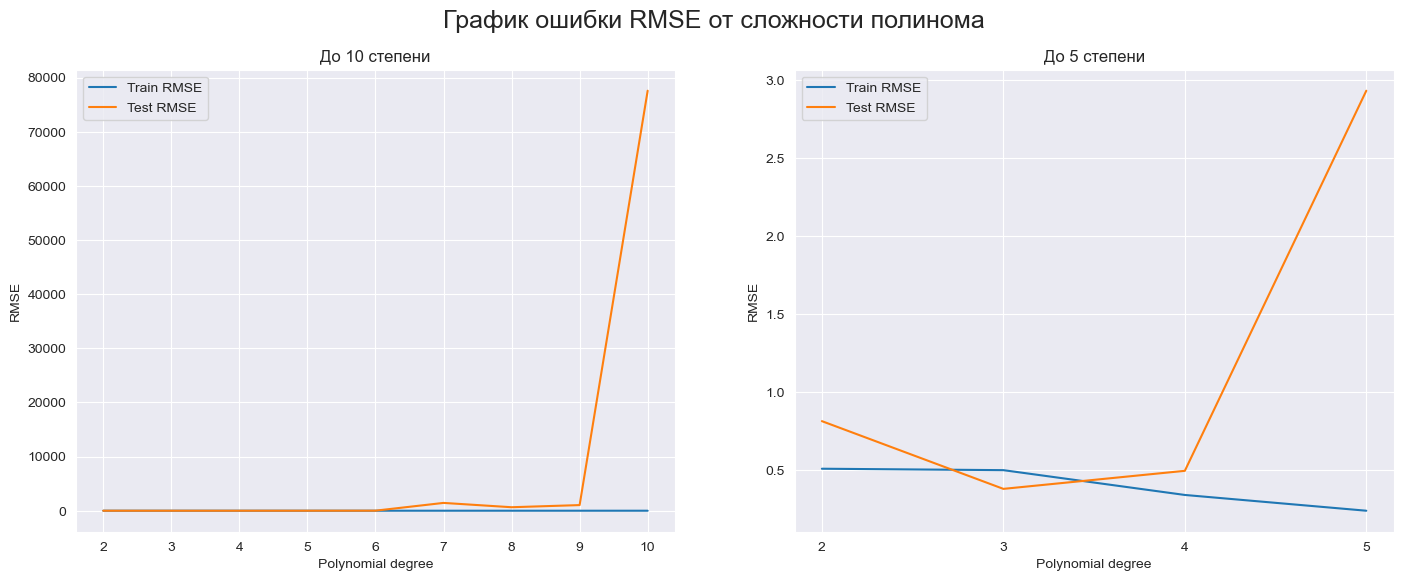

In [54]:
fig, ax = plt.subplots(1, 2, figsize=(17, 6))
fig.suptitle('График ошибки RMSE от сложности полинома', fontsize=18)
ax[0].set_title('До 10 степени')
ax[0].plot(range(2, 11), train_rmse_errors, label='Train RMSE')
ax[0].plot(range(2, 11), test_rmse_errors, label='Test RMSE')
ax[0].set_xlabel('Polynomial degree')
ax[0].set_ylabel('RMSE')
ax[0].legend()

ax[1].set_title('До 5 степени')
ax[1].plot(range(2, 6), train_rmse_errors[:4], label='Train RMSE')
ax[1].plot(range(2, 6), test_rmse_errors[:4], label='Test RMSE')
ax[1].set_xlabel('Polynomial degree')
ax[1].set_ylabel('RMSE')
ax[1].set_xticks(range(2, 6))
ax[1].legend()

## Таким образом, Полином 4-й степени показывает неплохие результаты, но так как именно с него начинается переобучение, лучше всего отступить в сторону полинома 3-й степени (или вообще оставить полином 2-й степени)

# Внедрение модели
Выбор пал на полином 3-й степени, поэтому буду сохранять `polynomial_features` именно с ним.

In [55]:
final_poly_converter = PolynomialFeatures(degree=3, include_bias=False)
final_model = LinearRegression()

full_converted_X = final_poly_converter.fit_transform(X)

final_model.fit(full_converted_X, y)

LinearRegression()

In [57]:
from joblib import dump, load
dump(final_model, 'polynomial_regression_model.joblib')
dump(final_poly_converter, 'polynomial_regression_converter.joblib')

['polynomial_regression_converter.joblib']

## Пример загрузки и применения модели и конвертера на новых данных

In [59]:
loaded_converter = load('polynomial_regression_converter.joblib')
loaded_model = load('polynomial_regression_model.joblib')

new_data = [[149, 22, 12]]

data = loaded_converter.transform(new_data)
pred = loaded_model.predict(data)
print(pred)

[14.64501014]


/opt/anaconda3/lib/python3.12/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(
